In [1]:
# Author: Ethan Dominic

# Import dependencies
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# The following code has been generated by ChatGPT 5.6
import statsmodels.api as sm

In [2]:
# 1. Dataset loading and cleaning

# Load the dataset.
churn_set = pd.read_csv("customer_churn.csv")
print(churn_set.columns)

# Clean the dataset.
churn_set = churn_set.drop(columns=['customerID']) # Remove the customer ID
churn_set["TotalCharges"] = churn_set["TotalCharges"].replace(' ', 0)
internet_dependent_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in churn_set[internet_dependent_cols]:
    churn_set[col] = churn_set[col].replace("No internet service")
churn_set["MultipleLines"] = churn_set["MultipleLines"].replace("No phone service")
churn_set.info()

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   obj

/tmp/ipykernel_24462/464646897.py:15: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  churn_set[col] = churn_set[col].replace("No internet service")
/tmp/ipykernel_24462/464646897.py:16: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  churn_set["MultipleLines"] = churn_set["MultipleLines"].replace("No phone service")


In [3]:
# Split the data into training and testing sets
churn_X = churn_set.drop(columns=["Churn"])
churn_y = churn_set["Churn"]
X_train, X_test, y_train, y_test = train_test_split(churn_X, churn_y, test_size=0.2, random_state=42)

In [4]:
# Ordinally encode the word columns (using Ordinal Encoding instead of One-Hot Encoding in order to keep the number of features to a minimum)
ore = OrdinalEncoder()
X_train_ordinal_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
X_train_transformed_ordinal_cols = pd.DataFrame(data=ore.fit_transform(X_train[X_train_ordinal_cols], y_train), columns=X_train_ordinal_cols, index=X_train.index)
X_train_non_ordinal_transformed_cols = X_train.drop(columns=X_train_ordinal_cols)
X_train_ordinal_transformed = pd.concat([X_train_transformed_ordinal_cols, X_train_non_ordinal_transformed_cols], axis=1)
X_train_ordinal_transformed.head(4)

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
2142,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,0,21,64.85,1336.8
1623,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,1.0,0.0,0,54,97.20,5129.45
6074,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0,1,23.45,23.45
1362,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0,4,70.20,237.95


In [5]:
# Standard scale the relevant numerical columns
std = StandardScaler()
X_train_std_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train_transformed_std_cols = pd.DataFrame(data=std.fit_transform(X_train_ordinal_transformed[X_train_std_cols], y_train), columns=X_train_std_cols, index=X_train_ordinal_transformed.index)
X_train_non_std_transformed_cols = X_train_ordinal_transformed.drop(columns=X_train_std_cols)
X_train_std_transformed = pd.concat([X_train_transformed_std_cols, X_train_non_std_transformed_cols], axis=1)
X_train_std_transformed.head(4)

,tenure,MonthlyCharges,TotalCharges,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen
2142,-0.465683,-0.000474,-0.419925,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,0
1623,0.885537,1.074754,1.256017,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,1.0,0.0,0
6074,-1.284605,-1.376499,-1.000283,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0
1362,-1.161766,0.177346,-0.905497,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0


In [6]:
# 2. EDA relevant to logistic regression assumptions.

# Binary outcome: The response is a category with two levels

# If the target (Churn) only has two values (0 and 1), this assumption has been met
print(churn_y.nunique() == 2)

# The binary outcome assumption has been met!

True


In [10]:
"""
Limited multicollinearity: Highly correlated predictors inflate standard errors
and make individual coefficients unstable, just as in linear regression.
"""
# Create a correlation matrix for all the numerical columns.
corr_matrix = X_train_std_transformed.corr()
print(corr_matrix)

"""
According to the correlation matrix, it appears that tenure highly correlates with
TotalCharges (given that there is a correlation value of 0.83), TotalCharges
moderately correlates with MonthlyCharges (approximately a correlation value of 0.65),
and tenure moderately correlates with Contract (approximately a correlation value of 0.67).
Therefore, I will opt to remove tenure's correlation with Contract is slightly higher
than that of TotalCharges' correlation with MonthlyCharges.
"""
X_train_std_transformed = X_train_std_transformed.drop(columns="tenure")

                    tenure  MonthlyCharges  TotalCharges    gender   Partner  \
tenure            1.000000        0.253803      0.828060  0.000682  0.378964   
MonthlyCharges    0.253803        1.000000      0.653769 -0.018287  0.105810   
TotalCharges      0.828060        0.653769      1.000000 -0.006569  0.320922   
gender            0.000682       -0.018287     -0.006569  1.000000 -0.007048   
Partner           0.378964        0.105810      0.320922 -0.007048  1.000000   
Dependents        0.162235       -0.112823      0.063443  0.009767  0.450438   
PhoneService      0.006502        0.249830      0.114962 -0.010919  0.029241   
MultipleLines     0.336939        0.422239      0.441143 -0.002940  0.143131   
InternetService  -0.033033       -0.321560     -0.175678 -0.004092  0.007858   
OnlineSecurity    0.292176        0.021410      0.257360 -0.012504  0.138414   
OnlineBackup      0.332691        0.154393      0.352349 -0.014621  0.145145   
DeviceProtection  0.332448        0.1696

In [11]:
"""
Sufficient sample size: A common rule of thumb is at least 10–20 events per predictor.
Sparse data leads to unreliable coefficients and over-fit decision boundaries.
"""

# Store the dimensions
dimensions = X_train_std_transformed.shape
num_rows = dimensions[0]
num_cols = dimensions[1]

# Report counts of missing values per column.
print("")
print("Number of Missing Values per Column:")
for col in X_train_std_transformed.columns:
    print(col + ": " + str(X_train_std_transformed[col].isna().sum()))
print("")

# Create a mapping of the columns to the corresponding percentages of values missing.
cols_to_percentage_missing = {}

# Print the percentage of values missing per column.
print("Percentage of Values Missing per Column:")
for col in X_train_std_transformed.columns:
    print(col + ": " + str(100*X_train_std_transformed[col].isna().sum()/num_rows) + "%")
    cols_to_percentage_missing[col] = 100*X_train_std_transformed[col].isna().sum()/num_rows
print("")


Number of Missing Values per Column:
MonthlyCharges: 0
TotalCharges: 0
gender: 0
Partner: 0
Dependents: 0
PhoneService: 0
MultipleLines: 0
InternetService: 0
OnlineSecurity: 0
OnlineBackup: 0
DeviceProtection: 0
TechSupport: 0
StreamingTV: 0
StreamingMovies: 0
Contract: 0
PaperlessBilling: 0
PaymentMethod: 0
SeniorCitizen: 0

Percentage of Values Missing per Column:
MonthlyCharges: 0.0%
TotalCharges: 0.0%
gender: 0.0%
Partner: 0.0%
Dependents: 0.0%
PhoneService: 0.0%
MultipleLines: 0.0%
InternetService: 0.0%
OnlineSecurity: 0.0%
OnlineBackup: 0.0%
DeviceProtection: 0.0%
TechSupport: 0.0%
StreamingTV: 0.0%
StreamingMovies: 0.0%
Contract: 0.0%
PaperlessBilling: 0.0%
PaymentMethod: 0.0%
SeniorCitizen: 0.0%



In [12]:
"""
There are no missing values in the train feature set as shown above. As a result,
if there are at least 10 observations, this test pass.
"""
print(num_rows > 10)

"""
There are at least 10 observations meaning that the Sufficient Sample Size assumption
has been met.
"""

True


'\nThere are at least 10 observations meaning that the Sufficient Sample Size assumption\nhas been met.\n'

In [13]:
# 3. Logistic Regression Model Code
model = LogisticRegression()
model.fit(X_train_std_transformed, y_train)

# Quickly transform the test set

# Ordinally encode the word columns (using Ordinal Encoding instead of One-Hot Encoding in order to keep the number of features to a minimum)
X_test_ordinal_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
X_test_transformed_ordinal_cols = pd.DataFrame(data=ore.transform(X_test[X_test_ordinal_cols]), columns=X_test_ordinal_cols, index=X_test.index)
X_test_non_ordinal_transformed_cols = X_test.drop(columns=X_test_ordinal_cols)
X_test_ordinal_transformed = pd.concat([X_test_transformed_ordinal_cols, X_test_non_ordinal_transformed_cols], axis=1)
X_test_ordinal_transformed.head(4)

# Standard scale the relevant numerical columns
X_test_std_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_test_transformed_std_cols = pd.DataFrame(data=std.transform(X_test_ordinal_transformed[X_test_std_cols]), columns=X_test_std_cols, index=X_test_ordinal_transformed.index)
X_test_non_std_transformed_cols = X_test_ordinal_transformed.drop(columns=X_test_std_cols)
X_test_std_transformed = pd.concat([X_test_transformed_std_cols, X_test_non_std_transformed_cols], axis=1)
X_test_std_transformed.head(4)

,tenure,MonthlyCharges,TotalCharges,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen
185,-1.284605,-1.331629,-0.999687,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0
2715,0.353238,-1.316672,-0.570322,1.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0
3825,0.803645,-1.512772,-0.554746,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,3.0,0
1807,-1.284605,0.381756,-0.976907,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0


In [14]:
# Drop the tenure column for consistency with the train set
X_test_std_transformed = X_test_std_transformed.drop(columns="tenure")

# Make the predictions
predictions = model.predict(X_test_std_transformed)

# 4. Model performance evidence

# Calculate the accuracy score of the trained model on the test set.
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

# The model's accuracy is approximately 82%.

Model Accuracy: 0.8183108587650816


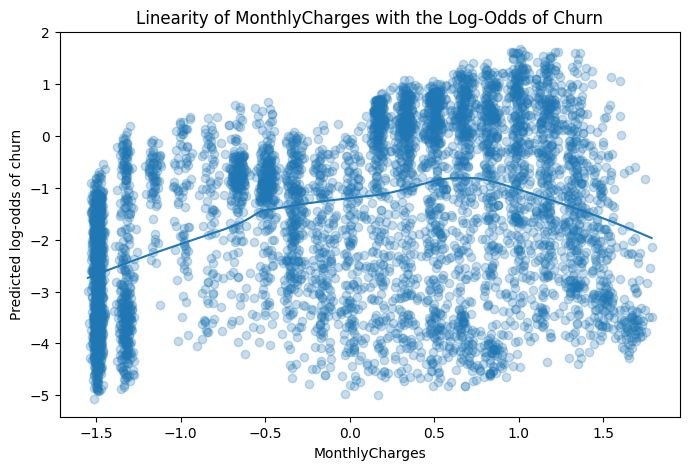

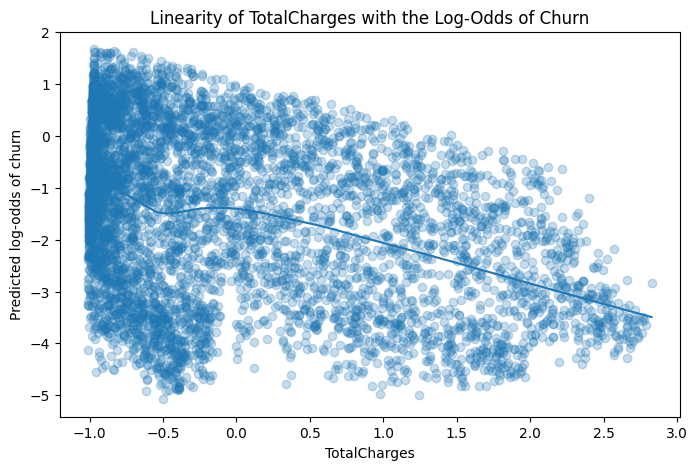

In [16]:
# The following code has been generated by ChatGPT 5.6
"""
(Check after training Logistic Regression model) Linear log-odds: The model assumes
each feature has a straight-line relationship with the log-odds of the outcome.
Non-linear effects need splines, interactions, or transformations.
"""
from statsmodels.nonparametric.smoothers_lowess import lowess

# Create a binary version of the training target.
y_train_binary = (y_train == "Yes").astype(int)

# Fit the logistic regression model's predicted probabilities.
train_probabilities = model.predict_proba(X_train_std_transformed)[:, 1]

# Convert probabilities to log-odds.
epsilon = 1e-10
train_log_odds = np.log(
    np.clip(train_probabilities, epsilon, 1 - epsilon) /
    np.clip(1 - train_probabilities, epsilon, 1)
)

continuous_predictors = ["MonthlyCharges", "TotalCharges"]

for predictor in continuous_predictors:
    predictor_values = X_train_std_transformed[predictor].values

    lowess_fit = lowess(
        train_log_odds,
        predictor_values,
        frac=0.6,
        return_sorted=True
    )

    plt.figure(figsize=(8, 5))
    plt.scatter(
        predictor_values,
        train_log_odds,
        alpha=0.25
    )
    plt.plot(
        lowess_fit[:, 0],
        lowess_fit[:, 1]
    )
    plt.xlabel(predictor)
    plt.ylabel("Predicted log-odds of churn")
    plt.title(f"Linearity of {predictor} with the Log-Odds of Churn")
    plt.show()

**Unfortunately, it appears that the relationship between the predicted log-odds of churn and MonthlyCharges is not entirely linear and the same can be said for the relationship between the predicted log-odds of churn and TotalCharges. Therefore, this assumptions has not been met.**

In [17]:
# The following code has been generated by ChatGPT 5.6

# 5. Coefficient or odds-ratio interpretation in markdown.

# Extract the coefficients from the trained logistic regression model.
coefficients = model.coef_[0]

# Create a table containing coefficients and odds ratios.
coefficient_table = pd.DataFrame({
    "Feature": X_train_std_transformed.columns,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

coefficient_table = coefficient_table.sort_values(
    by="Odds_Ratio",
    ascending=False
)

print(coefficient_table)

             Feature  Coefficient  Odds_Ratio
0     MonthlyCharges     0.993669    2.701127
15  PaperlessBilling     0.350657    1.420000
7    InternetService     0.187265    1.205947
17     SeniorCitizen     0.178698    1.195659
16     PaymentMethod     0.102647    1.108100
13   StreamingMovies     0.071724    1.074359
6      MultipleLines     0.061001    1.062900
12       StreamingTV     0.008444    1.008480
3            Partner    -0.002972    0.997033
2             gender    -0.051308    0.949986
10  DeviceProtection    -0.092983    0.911209
4         Dependents    -0.198697    0.819798
9       OnlineBackup    -0.250586    0.778345
11       TechSupport    -0.378103    0.685160
8     OnlineSecurity    -0.502012    0.605311
1       TotalCharges    -0.723948    0.484834
5       PhoneService    -0.899695    0.406694
14          Contract    -0.908069    0.403302


# 6. At least one limitation of using logistic regression for churn.

**One limitation of using logistic regression for churn is that the assumptions (particularly the linearity with log-odds assumption) have not fully been met, leading to a subpar accuracy for predicting churn.**